Epoch 1/500


d:\Behvaior Analysis\banalysis\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1220 - loss: 2.4522 - val_accuracy: 0.2163 - val_loss: 2.2987
Epoch 2/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2478 - loss: 2.2196 - val_accuracy: 0.3104 - val_loss: 2.0694
Epoch 3/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3488 - loss: 1.9663 - val_accuracy: 0.3778 - val_loss: 1.8833
Epoch 4/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4193 - loss: 1.7811 - val_accuracy: 0.4297 - val_loss: 1.7385
Epoch 5/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4716 - loss: 1.6365 - val_accuracy: 0.4730 - val_loss: 1.6442
Epoch 6/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5128 - loss: 1.5266 - val_accuracy: 0.4910 - val_loss: 1.5819
Epoch 7/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5383 - loss: 1.4407 - val_accuracy: 0.5188 - val_loss: 1.5048
Epoch 8/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5637 - loss: 1.3739 - val_accuracy: 0.5436

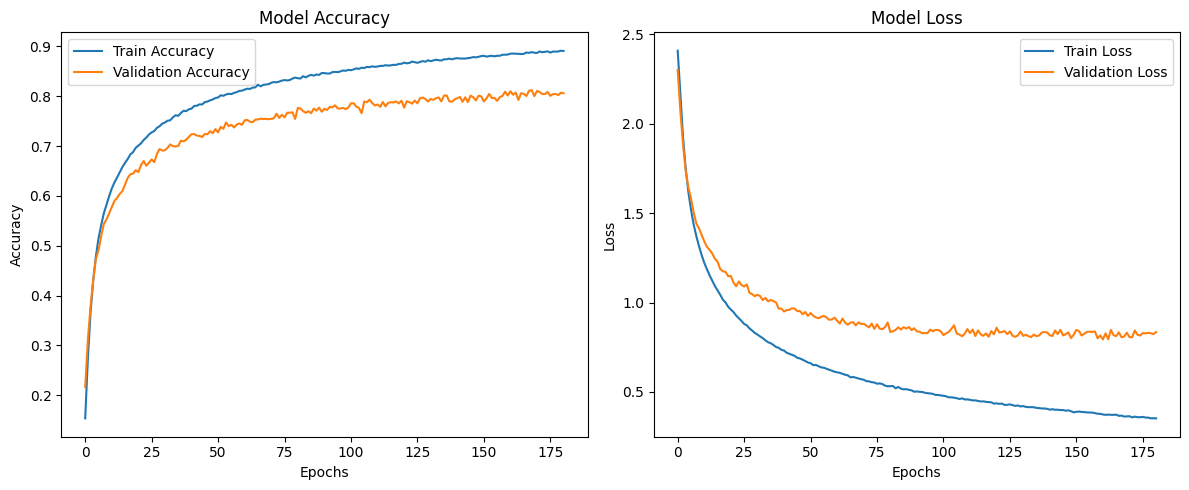

Model saved as '1d_cnn_multiclass_model.h5'


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Step 1: Load and Preprocess Data
resampled_data = pd.read_csv('resampled_data.csv')

# Separate features (X) and target (y)
# Assuming the target variable is the last column in the dataset, modify if different
X = resampled_data.iloc[:, :-1].values  # All columns except the last
y = resampled_data.iloc[:, -1].values   # The last column is the target

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape X to be 3D for CNN (samples, time steps, features)
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

# Encode the target labels for multiclass classification
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_one_hot = to_categorical(y_encoded)  # Convert labels to one-hot encoding

# Step 2: Split data into 80% train, 10% validation, and 10% test sets
X_train, X_temp, y_train, y_temp = train_test_split(X_reshaped, y_one_hot, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Step 3: Build the 1D CNN Model
model = Sequential()

# Add the first convolutional layer
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))

# Add a max pooling layer
model.add(MaxPooling1D(pool_size=2))

# Add additional convolutional layers if needed
model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))

# Flatten the output from the convolutional layers
model.add(Flatten())

# Add a fully connected layer
model.add(Dense(64, activation='relu'))

# Add the output layer
model.add(Dense(y_one_hot.shape[1], activation='softmax'))  # Number of classes in the output layer

# Step 4: Compile the Model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Step 5: Add Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Step 6: Train the Model
history = model.fit(X_train, y_train, epochs=500, batch_size=128, validation_data=(X_val, y_val), callbacks=[early_stopping])

# Step 7: Evaluate the Model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Loss: {test_loss:.4f}')

# Step 8: (Optional) Visualize the Training Process
# Plot training and validation accuracy/loss
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Step 9: Save the Model
model.save('1d_cnn_multiclass_model.h5')  # Save the model in HDF5 format
print("Model saved as '1d_cnn_multiclass_model.h5'")


375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8040 - loss: 0.8586
Test Accuracy: 0.8070
Test Loss: 0.8454
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1059
           1       0.77      0.81      0.79       986
           2       0.82      0.83      0.82       971
           3       0.84      0.85      0.85      1039
           4       0.77      0.75      0.76       992
           5       0.82      0.80      0.81      1080
           6       0.79      0.77      0.78      1008
           7       0.81      0.81      0.81       942
           8       0.78      0.81      0.79       956
           9       0.81      0.79      0.80      1006
          10       0.85      0.78      0.81      1008
          11       0.79      0.82      0.80       953

    accuracy                           0.81     12000
   macro avg       0.81      0.81      0.81     12

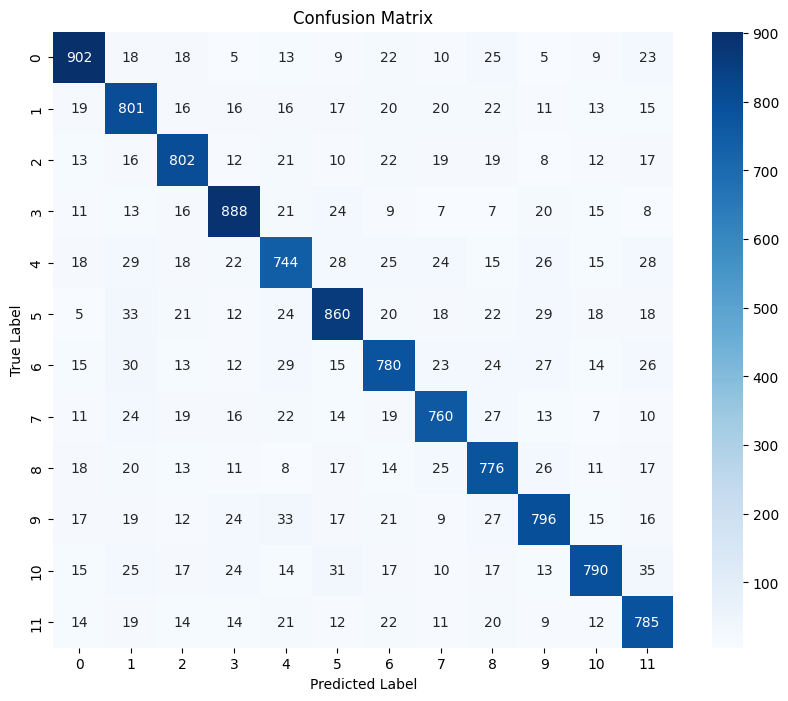

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load the resampled_data.csv
resampled_data = pd.read_csv('resampled_data.csv')

# Separate features (X) and target (y)
X = resampled_data.iloc[:, :-1].values  # All columns except the last
y = resampled_data.iloc[:, -1].values   # The last column is the target

# Standardize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape X to be 3D for CNN (samples, time steps, features)
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

# Encode the target labels for multiclass classification
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_one_hot = pd.get_dummies(y_encoded).values  # Convert labels to one-hot encoding

# Split the data into 80% train, 10% validation, and 10% test sets
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X_reshaped, y_one_hot, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Load the trained model
model = load_model('1d_cnn_multiclass_model.h5')

# Step 1: Evaluate the Model on the Test Set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Loss: {test_loss:.4f}')

# Step 2: Predict on the Test Set
y_pred = model.predict(X_test)

# Convert the predictions from one-hot encoding to labels
y_pred_labels = np.argmax(y_pred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

# Step 3: Classification Report
print("\nClassification Report on Test Set:")
# Convert label_encoder.classes_ to string labels
target_names = [str(label) for label in label_encoder.classes_]
print(classification_report(y_test_labels, y_pred_labels, target_names=target_names))

# Step 4: Confusion Matrix
conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


Epoch 1/500


d:\Behvaior Analysis\banalysis\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.1085 - loss: 2.4693 - val_accuracy: 0.1925 - val_loss: 2.3482
Epoch 2/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2367 - loss: 2.2403 - val_accuracy: 0.3498 - val_loss: 1.9608
Epoch 3/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3913 - loss: 1.8385 - val_accuracy: 0.4593 - val_loss: 1.6482
Epoch 4/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5085 - loss: 1.5106 - val_accuracy: 0.5302 - val_loss: 1.4214
Epoch 5/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5887 - loss: 1.2790 - val_accuracy: 0.5987 - val_loss: 1.2633
Epoch 6/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6360 - loss: 1.1205 - val_accuracy: 0.6273 - val_loss: 1.1612
Epoch 7/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6819 - loss: 0.9909 - val_accuracy: 0.6668 - val_loss: 1.0404
Epoch 8/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7144 - loss: 0.8869 - val_accuracy: 0.6876

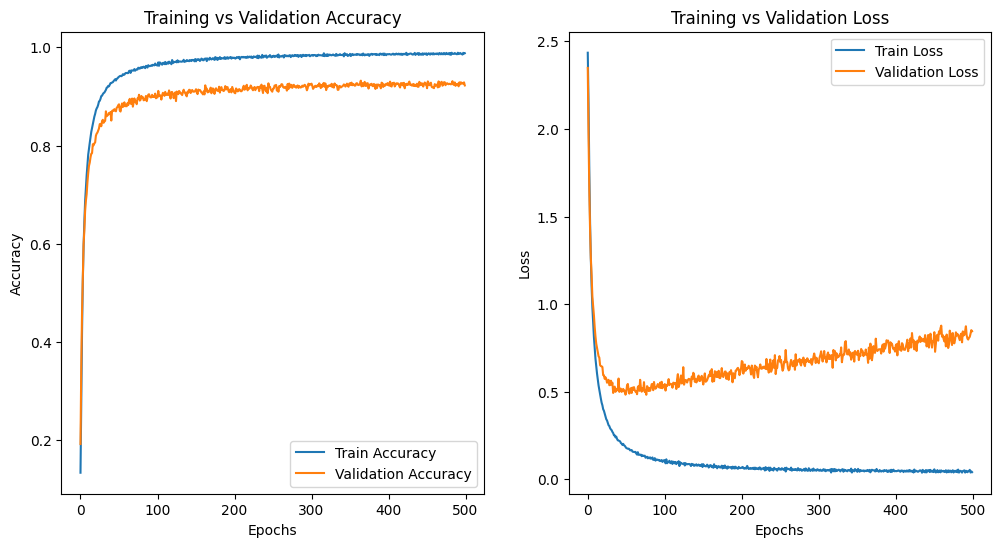

CNN model saved to 'cnn_model.h5'
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1059
           1       0.92      0.94      0.93       986
           2       0.92      0.93      0.93       971
           3       0.95      0.94      0.94      1039
           4       0.91      0.94      0.92       992
           5       0.95      0.91      0.93      1080
           6       0.93      0.92      0.93      1008
           7       0.93      0.93      0.93       942
           8       0.94      0.93      0.93       956
           9       0.94      0.94      0.94      1006
          10       0.94      0.94      0.94      1008
          11       0.92      0.94      0.93       953

    accuracy                           0.93     12000
   macro avg       0.93      0.93      0.93     12000
weight

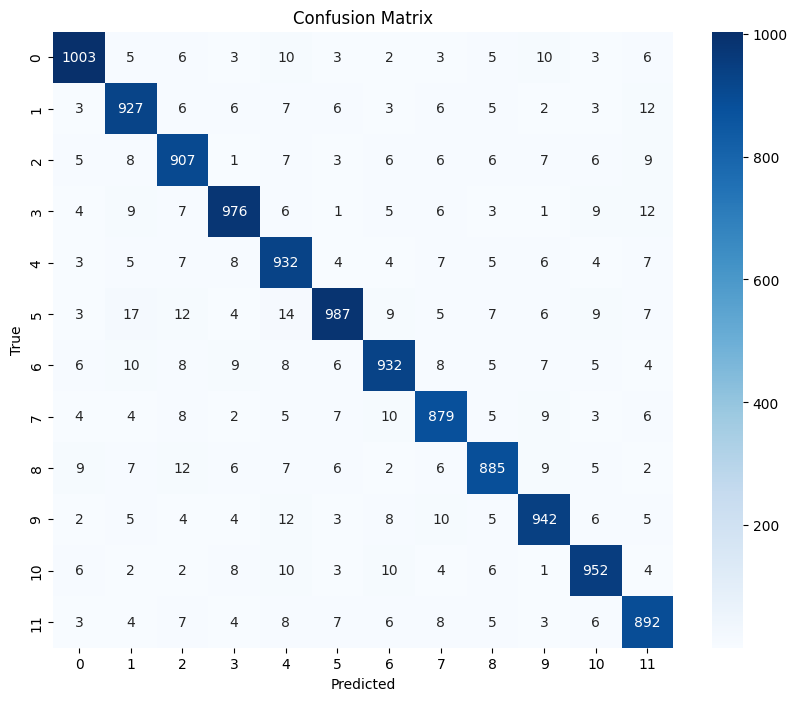

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from keras.optimizers import Adam
from keras.utils import to_categorical
from keras.models import load_model
import seaborn as sns

# Load your CSV data
csv_file = 'resampled_data.csv'  # Update with the path to your CSV file
df = pd.read_csv(csv_file)

# Assuming your CSV file has a 'Suggested Job Role' column as the target and the rest are features
X = df.drop(columns=['Suggested Job Role']).values  # Drop 'label' column to get features
y = df['Suggested Job Role'].values  # The target column

# Convert labels to one-hot encoding for multi-class classification
y = to_categorical(y)  # This converts labels to one-hot encoded vectors

# Reshape X to fit into 1D-CNN
X = X.reshape(X.shape[0], X.shape[1], 1)  # Shape should be (samples, timesteps, features)

# Split the data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Define the 1D CNN model
cnn_model = Sequential()
cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Conv1D(128, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(y_train.shape[1], activation='softmax'))  # Softmax for multi-class output

# Compile the CNN model
cnn_model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])  # Use categorical_crossentropy for multi-class

# Train the CNN model and capture the history for plotting
history = cnn_model.fit(X_train, y_train, epochs=500, batch_size=128, validation_data=(X_val, y_val))

# Plot training and validation accuracy and loss
plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Save the trained CNN model
cnn_model.save('cnn_model.h5')  # Save the model as a .h5 file
print("CNN model saved to 'cnn_model.h5'")

# Extract features from the trained CNN
cnn_features_train = cnn_model.predict(X_train)
cnn_features_val = cnn_model.predict(X_val)
cnn_features_test = cnn_model.predict(X_test)

# Flatten the features into 1D arrays for Random Forest input
cnn_features_train = cnn_features_train.reshape(cnn_features_train.shape[0], -1)
cnn_features_val = cnn_features_val.reshape(cnn_features_val.shape[0], -1)
cnn_features_test = cnn_features_test.reshape(cnn_features_test.shape[0], -1)

# Train a Random Forest classifier on the CNN features
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(cnn_features_train, np.argmax(y_train, axis=1))  # Convert one-hot to label index

# Make predictions
y_pred = rf_model.predict(cnn_features_test)

# Evaluate the hybrid model
print("Classification Report:")
print(classification_report(np.argmax(y_test, axis=1), y_pred))  # Convert one-hot to label index for evaluation

# Compute the confusion matrix
cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(y_test.shape[1]), yticklabels=np.arange(y_test.shape[1]))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
